# 待解決問題
1. 某個record會預測出對應sample_time的target data，但這個target data並不是因為單一record所導致的，而是因為一段record造成的

# 描述性統計
## 變異性
1. 總體變異程度
2. sample slot內的變異程度

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from tqdm import tqdm

# from cuml.model_selection import train_test_split
# from cuml.ensemble import RandomForestRegressor
# from cuml.metrics import mean_squared_error, r2_score
# from cuml.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.rnn as rnn_utils
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit

In [2]:
result: dict[str, pd.DataFrame] = {}

for file in os.listdir("./processed_data"):
    if file.endswith(".csv"):
        df:pd.DataFrame = pd.read_csv(f"./processed_data/{file}")
        df['sample_time'] = pd.to_datetime(df['sample_time'])
        result[f'{file.replace(".csv", "")}'] = df

result_keys = list(result.keys())

sample_times = result[result_keys[0]]['sample_time'].unique()

C:\Users\蔡世玄\AppData\Local\Temp\ipykernel_40912\2926703907.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df:pd.DataFrame = pd.read_csv(f"./processed_data/{file}")


In [7]:
# KDA和時間序列圖
for col in result["API"].columns:
    if col not in ['TimeStamp', "Batch", "sample_time", "sample_id"]:
        plt.figure(figsize=(20, 5))
        
        # 如果是二元值
        if result['API'][col].unique().shape[0] == 2:
            plt.scatter(result['API']['TimeStamp'], result['API'][col], alpha=0.5)  # 繪製散點圖
            plt.yticks([0, 1])  # 限制 Y 軸為 0 和 1
        else:
            plt.plot(result['API']["TimeStamp"], result['API'][col])
        
        for sample_time in sample_times:
            plt.axvline(sample_time, color='r', linestyle='--')

        plt.title(col)
        plt.xlabel('Value', fontsize=16)
        plt.show()

KeyError: 'API'

# 數據分析

## 策略
1. 先將資料依照sample_time分組
2. 先用F檢定來找出顯著變數，再來使用機器學習方法來做預測
3. 使用PCA作為比較基礎

## 機器學習方法
1. 隨機森林回歸
2. XGboot

In [8]:
class PCAProcessor:
    def __init__(self, name: str, model_path: str = '/model',n_components=None):
        """
        PCAProcessor 類別，用於處理數據降維
        :param n_components: 主成分數，None 表示自動選擇可解釋 95% 變異數的成分數
        """
        self.n_components = n_components
        self.pca = None  # 初始化 PCA 物件
        self.model_path = model_path # 儲存模型路徑
        self.name = name # 儲存模型名稱

    def fit_transform(self, X: np.ndarray, save_model=True) -> np.ndarray:
        """
        擬合並轉換數據，並可選擇是否儲存 PCA 模型
        :param X: 原始數據 (np.ndarray)
        :param save_model: 是否儲存 PCA 模型，預設為 True
        :return: 降維後的數據
        """
        from sklearn.decomposition import PCA  # 避免 cuML 環境問題

        if self.n_components is None:
            self.pca = PCA(n_components=0.95)  # 自動選擇可解釋 95% 變異數的主成分數
        else:
            self.pca = PCA(n_components=self.n_components)

        X_transformed = self.pca.fit_transform(X)
        print(f"PCA reduced features to {self.pca.n_components_} dimensions")

         # **🚀 自動儲存 PCA 模型**
        if save_model:
            self._save_model()

        return X_transformed

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        轉換新的數據 (測試集)
        :param X: 原始數據 (np.ndarray)
        :return: 降維後的數據
        """
        
        if self.pca is None:
            print(f"PCA model has not been fitted, try to load the {self.name}...")
            self.pca = self._load_model()

        return self.pca.transform(X)
    
    def _save_model(self):
        """
        儲存self.pca model到model path
        """
        joblib.dump(self.pca, self.model_path)

    def _load_model(self):
        """
        載入 PCA 模型
        """
        if not os.path.exists(self.model_path):
            raise FileNotFoundError(f"PCA 模型 {self.model_path} 不存在，請先執行 fit_transform()")
        self.pca = joblib.load(self.model_path)
        print(f"PCA 模型已從 {self.model_path} 載入")

In [9]:
class TimeSeriesRandomForestRegressor:
    def __init__(self, model_name, df: pd.DataFrame, target: list[str], feature: list[str] = None, folds: int = 5, n_estimators=10, random_state=42):
        self.df = df.sort_values(by="TimeStamp")  # ✅ 確保數據按照時間排序
        self.target = target
        self.feature = feature
        self.model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
        self.model_name = model_name
        self.folds = folds

    def train(self) -> None:
        # 1. 選擇特徵
        feature_df = self.df

        # drop不會使用到的特徵
        feature_df = feature_df.drop(columns=["TimeStamp", 'Batch', 'sample_id'] + self.target)

        y = self.df[['sample_time'] + self.target]

        # 2. 將data依照sample time分組
        X_group = feature_df.groupby('sample_time')
        y = y.drop_duplicates()

        _sample_times = list(y['sample_time'])

        X_list = []
        y_list = []

        # 找出最小的group size來保證每個sample的target會是一樣的
        lookback = min([len(X_group.get_group(_sample_time)) for _sample_time in _sample_times])
        
        # 3. 使用lookback得分組資料分批訓練模型
        for sample_time in _sample_times:
            group_X = X_group.get_group(sample_time).drop(columns=['sample_time']) # 取得該時間點的所有X
            group_X = group_X.iloc[len(group_X) - lookback:,:] # 取得lookback筆數據
            group_y = y[y.loc[:, 'sample_time'] == sample_time].drop(columns=['sample_time']).values.mean() # 取得該sample的目標陣列
        
            # 加入train_list中
            X_list.append(group_X.values.flatten()) # 展成一維數據
            y_list.append(group_y) # 展成一維數據

        # 4. 將feature和target轉換成np.array
        X = np.array(X_list)
        y = np.array(y_list)
        
        X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, shuffle=False)
        y_train, y_test = train_test_split(y, test_size=0.2, random_state=42, shuffle=False)

        # 設定時間序列交叉驗證
        tscv = TimeSeriesSplit(n_splits=self.folds)

        mse_scores = []
        r2_scores = []

        # 進行時間序列交叉驗證
        for fold, (train_index, test_index) in enumerate(tqdm(tscv.split(X_train), total=self.folds, desc="Time Series Cross Validation"), start=1):
            # 分train和valid set
            X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
            y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]
            

            # 做訓練
            self.model.fit(X_train_fold, y_train_fold)
            y_pred_fold = self.model.predict(X_test_fold)
            mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
            r2_fold = r2_score(y_test_fold, y_pred_fold)
            mse_scores.append(mse_fold)
            r2_scores.append(r2_fold)

        print(f"Time Series Cross Validation MSE Mean: {np.mean(mse_scores)}")
        print(f"Time Series Cross Validation R² Mean: {np.mean(r2_scores)}")

        # **4. 使用最終訓練集來訓練模型**
        self.model.fit(X_train, y_train)
        y_pred = self.model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Final Test MSE: {mse}")
        print(f"Final Test R²: {r2}")

        print(len(y_pred))
        # **5. 將預測點與實際點視覺化**
        self.diagram(y_pred, y_test, len(y_pred))

        # **6. 將model儲存
        joblib.dump(self.model, f"./model/{self.model_name}.pkl")
        print(f"Model saved to ./model/{self.model_name}.pkl") 

    # 丟進一些資料，透過這些資料預測結果
    def diagram(self, y_pred: np.ndarray, y_test: np.ndarray, sample_time_index: int) -> None:        
        plt.figure(figsize=(20, 5))
        _sample_times = self.df["sample_time"].unique() # return date array

        _sample_times = _sample_times[-sample_time_index:]

        # **確保 sample_times 為 X 軸**
        plt.plot(_sample_times, y_pred, label="Predicted Value", linestyle="--", marker="o")
        plt.plot(_sample_times, y_test, label="Actual Value", linestyle="-", marker="x")

        plt.xlabel("Sample Time")
        plt.ylabel("Value")
        plt.xticks(rotation=45)  # 旋轉 X 軸標籤，方便閱讀
        plt.title(f"Tablet Prediction")
        plt.legend()
        plt.grid()
        plt.show()


/workspace/MSOM_data_driven/env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:368: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)
Time Series Cross Validation:   0%|          | 0/5 [00:00<?, ?it/s]/workspace/MSOM_data_driven/env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:193: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  ret = func(*args, **kwargs)
Time Series Cross Validation: 100%|██████████| 5/5 [00:18<00:00,  3.67s/it]


Time Series Cross Validation MSE Mean: 0.0054908960149502905
Time Series Cross Validation R² Mean: -0.30351418771771776
Final Test MSE: 0.004430827684191705
Final Test R²: -0.017664938775771688
43


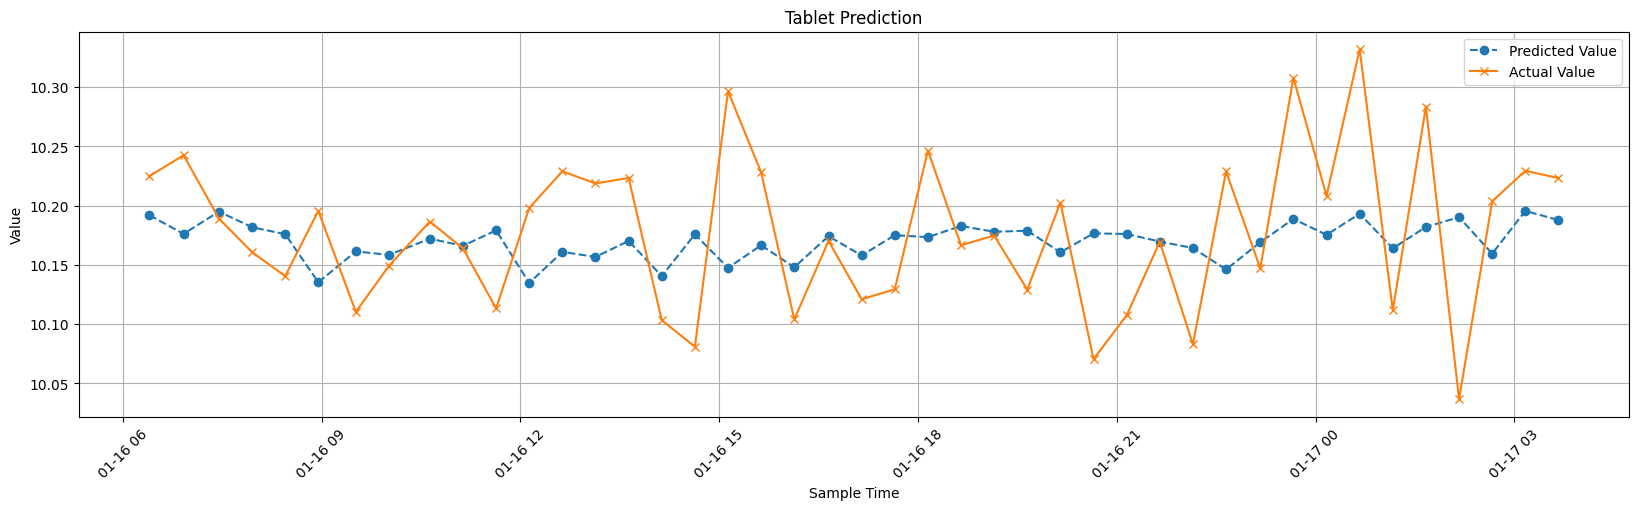

Model saved to ./model/API.pkl


In [ ]:
# 直接做training
# 用targets的平均值做為目標
targets = ['Tablet 1', 'Tablet 2', 'Tablet 3', 'Tablet 4', 'Tablet 5', 'Tablet 6', 'Tablet 7', 'Tablet 8', 'Tablet 9', 'Tablet 10']
model = TimeSeriesRandomForestRegressor(model_name=f"API", df=result['API'], target=targets, folds=5, n_estimators=100)
model.train()

PCA reduced features to 10 dimensions


/workspace/MSOM_data_driven/env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:368: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)
Time Series Cross Validation:   0%|          | 0/5 [00:00<?, ?it/s]/workspace/MSOM_data_driven/env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:193: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  ret = func(*args, **kwargs)
Time Series Cross Validation: 100%|██████████| 5/5 [00:03<00:00,  1.28it/s]


Time Series Cross Validation MSE Mean: 0.012398995476601078
Time Series Cross Validation R² Mean: -1.5940095150580655
Final Test MSE: 0.007521840544833521
Final Test R²: -0.7276034960351965
43


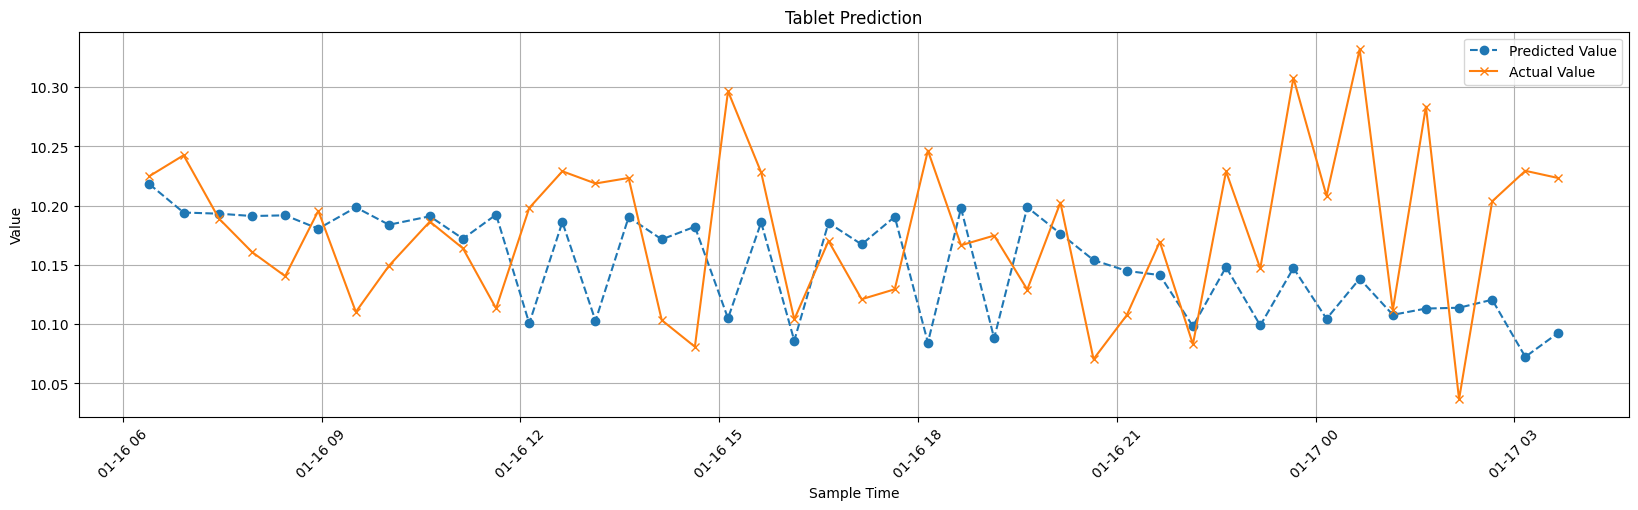

Model saved to ./model/API_PCA.pkl


In [ ]:
# 先做PCA，再train model
# 用targets的平均值作為目標
pca = PCAProcessor(name='API_PCA', n_components=10)

X = result['API'].drop(columns=["TimeStamp", 'Batch', 'sample_id', 'sample_time'])
meta_columns = result['API'][["TimeStamp", 'Batch', 'sample_id', 'sample_time']]
y = result['API'][targets]

X_train, X_test = train_test_split(X=X, shuffle=False)

# 訓練數據，fit_transfrom
X_train_pca = pca.fit_transform(X_train.to_numpy())

# 測試數據，transfrom
X_test_pca = pca.transform(X_test.to_numpy())

# 合併pca後的數據，並轉換成X_pca_df
X_pca = np.vstack([X_train_pca, X_test_pca])
X_pca_df = pd.DataFrame(X_pca)

# 將sample_time合併進去
X_pca_df = pd.concat([X_pca_df, meta_columns, y], axis=1)
# 進行訓練與預測
regressor = TimeSeriesRandomForestRegressor(model_name='API_PCA', df = X_pca_df, target=targets, n_estimators=100)

regressor.train()

In [26]:
class LSTM_Model:
    def __init__(self, model_name, input_size: int, hidden_size: int, num_layers: int, output_size: int, epoch: int, lr: int, folds: int = 5):
        # 模型基本資訊
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_layer = num_layers

        # 確認GPU
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # 建立LSTM模型
        self.model = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True).to(self.device)
        self.fc = nn.Linear(hidden_size, output_size).to(self.device)
        self.epochs = epoch
        self.lr = lr
        self.criterion = nn.MSELoss()
        self.optimizer = None # optimizer 在 train 內初始化
        
        self.model_name = model_name
        self.folds = folds
        self.feature = None
        self.sample_times = None

    def forward(self, x):
        # 將x移動到GPU
        x = x.to(self.device)
        
        # LTSM運算，output出一個seq_len的序列, 時間從t-seq_len到t
        # LTSM output: (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.model(x) 

        # 取出t時間點的output
        # 進行fully connective 運算
        # 輸出output_size大小的運算結果 => 預測值
        out = self.fc(lstm_out[:, -1, :])  # 取最後一個TimeStep
        return out
    
    def _create_variable_seq_data(self, df: pd.DataFrame, feature: list[str], target: list[str]) -> DataLoader:
        X_list, y_list = [], []

        # 透過sample_time分群
        group_df = df[feature + target].groupby('sample_time')

        # 依照分群加到list中
        for _, group in group_df:
            # 二維df (seq_len, input_size)
            X_seq = group[self.feature].drop(columns=['sample_time']).values

            # 一維 (output_size)
            y_seq = group[target].iloc[-1]

            # 加到三維list
            X_list.append(X_seq)

            # 加到二維list (batch_size, output_size)
            y_list.append(y_seq)

        max_seq_len = 10 # 每次會回頭看max_seq_len的值

        # 建立一個形狀為 (batch_size, max_seq_len, input_size) 的零矩陣
        X_padded = np.zeros((len(X_list), max_seq_len, self.input_size))

        # 將X_list內第i行的數據填到X_padded第i行和第len(X)的位置
        # 三維
        for i, x in enumerate(X_list):
            X_padded[i, :max_seq_len, :] = x[:max_seq_len, :]

         # 標準化 X
        X_reshaped = X_padded.reshape(-1, X_padded.shape[-1])  # 轉成 2D
        scaler_X = MinMaxScaler(feature_range=(0, 1))
        X_scaled = scaler_X.fit_transform(X_reshaped)  # 標準化
        X = X_scaled.reshape(X_padded.shape)  # 轉回 3D

        # 標準化 y
        scaler_y = MinMaxScaler(feature_range=(0, 1))
        y_scaled = scaler_y.fit_transform(np.array(y_list))

        # 3維 (batch_size, max_seq_len = 最長的X, input_size = len(features))
        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        # 2維 (batch_size, output_size=len(target))
        y = torch.tensor(y_scaled, dtype=torch.float32).to(self.device) 
        
        # batch_size
        batch_size = len(X_list)//5
        
        print(X.shape)
        print(y.shape)

        # 創建 TensorDataset
        dataset = TensorDataset(X, y)

        # 使用 DataLoader 來批量讀取數據
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        return dataloader

    def train(self, df: pd.DataFrame, target: list[str], feature: list[str] = None) -> dict[str, float]:
        df = df.sort_values(by="sample_time")  # 確保數據按時間排序
        # 紀錄sample_times
        self.sample_times = list(df['sample_time'].astype(str).unique())

        # 選擇特徵
        self.feature = feature if feature else list(df.columns.difference(["TimeStamp", "Batch", "sample_id"] + target))

        dataloader = self._create_variable_seq_data(df=df, feature=self.feature, target=target)

        # 劃分數據集 (80% 訓練, 20% 測試)
        train_size = int(0.8 * len(dataloader.dataset))
        test_size = len(dataloader.dataset) - train_size

        train_dataset = torch.utils.data.Subset(dataloader.dataset, range(0, train_size))
        test_dataset = torch.utils.data.Subset(dataloader.dataset, range(train_size, len(dataloader.dataset)))

        train_loader = DataLoader(train_dataset, batch_size=dataloader.batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=dataloader.batch_size, shuffle=False)

        
        # 初始化Optimizer
        self.optimizer = optim.Adam(list(self.model.parameters()) + list(self.fc.parameters()), lr = self.lr)

        # 開啟train mode
        self.model.train()
        
        # 使用 tqdm 來顯示進度條
        progress_bar = tqdm(range(self.epochs), desc=f"{self.num_layer}_{self.hidden_size}_{self.epochs}_{self.lr}_Training Progress", unit="epoch")

        for epoch in progress_bar:
            epoch_loss = 0
            for X_train_batch, y_train_batch in train_loader:
                self.optimizer.zero_grad()

                # predction
                y_pred = self.forward(X_train_batch)

                # 計算loss並回傳
                loss = self.criterion(y_pred, y_train_batch)
                loss.backward()

                # 優化model
                self.optimizer.step()

                epoch_loss += loss.item()

            
            # 平均 loss
            avg_loss = epoch_loss / len(train_loader)
            progress_bar.set_postfix({"Loss": f"{avg_loss:.4f}"})

        # 評估模型
        self.model.eval()
        y_preds, y_tests = [], []
        with torch.no_grad():
            for X_test_batch, y_test_batch in test_loader:
                y_pred = self.forward(X_test_batch)
                y_preds.append(y_pred.cpu().numpy())
                y_tests.append(y_test_batch.cpu().numpy())

        y_preds = np.concatenate(y_preds, axis=0)
        y_tests = np.concatenate(y_tests, axis=0)

        mse = mean_squared_error(y_tests, y_preds)
        r2 = r2_score(y_tests, y_preds)

        
        # 視覺化
        fig = self.diagram(y_preds, y_tests, len(y_pred))

        # 將model儲存
        torch.save({'model': self.model.state_dict(), "fc": self.fc.state_dict()}, f"model/{self.num_layer}_{self.hidden_size}_{self.epochs}_{self.lr}_{self.model_name}.pth")

        return {"mse": mse, "r2": r2, "fig": fig}
    
    # 丟進一些資料，透過這些資料預測結果
    def diagram(self, y_pred: np.ndarray, y_test: np.ndarray, sample_time_index: int) -> None:        
        fig = plt.figure(figsize=(20, 5))
        _sample_times = self.sample_times[-sample_time_index:]

        # **確保 sample_times 為 X 軸**
        plt.plot(_sample_times, y_pred, label="Predicted Value", linestyle="--", marker="o")
        plt.plot(_sample_times, y_test, label="Actual Value", linestyle="-", marker="x")

        plt.xlabel("Sample Time")
        plt.ylabel("Value")
        plt.xticks(rotation=45)  # 旋轉 X 軸標籤，方便閱讀
        plt.title(f"Tablet Prediction")
        plt.legend()
        plt.grid()
        plt.show()

        return fig
            

torch.Size([215, 10, 78])
torch.Size([215, 10])


2_16_50_0.0001_Training Progress: 100%|██████████| 50/50 [00:01<00:00, 34.14epoch/s, Loss=0.0628]


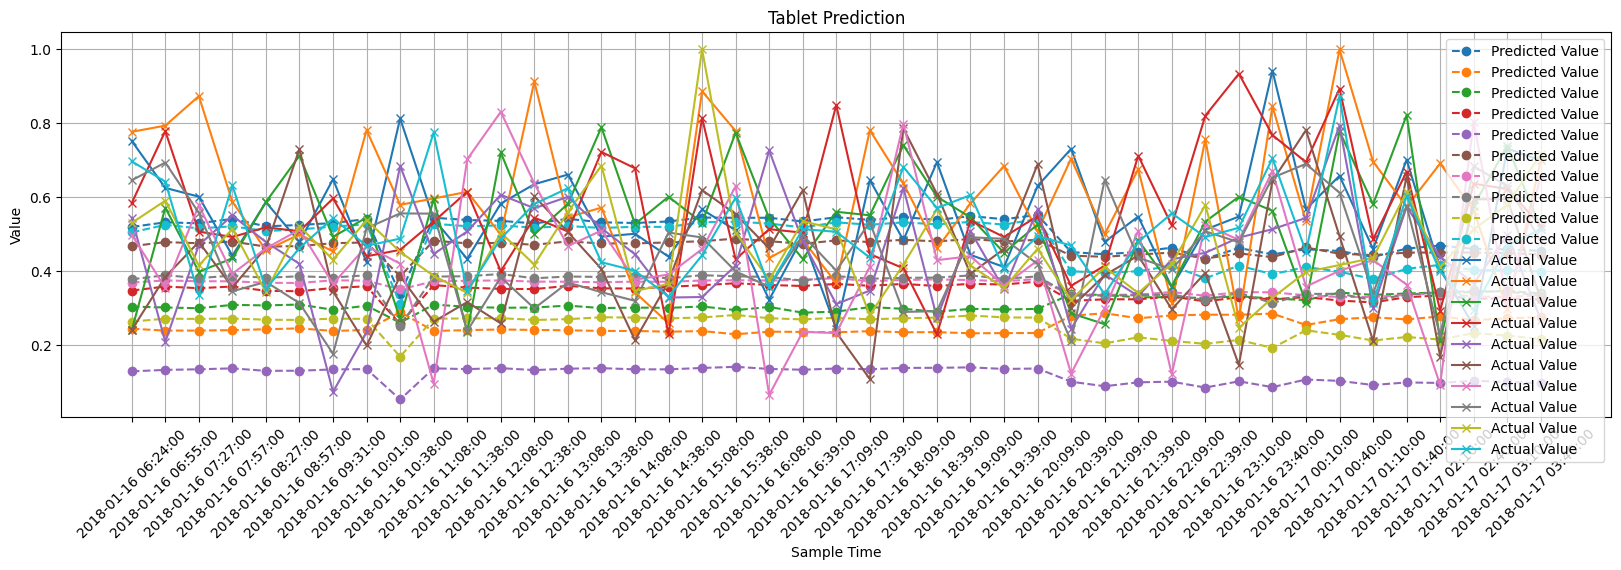

torch.Size([215, 10, 78])
torch.Size([215, 10])


2_16_50_0.001_Training Progress: 100%|██████████| 50/50 [00:01<00:00, 30.78epoch/s, Loss=0.0294]


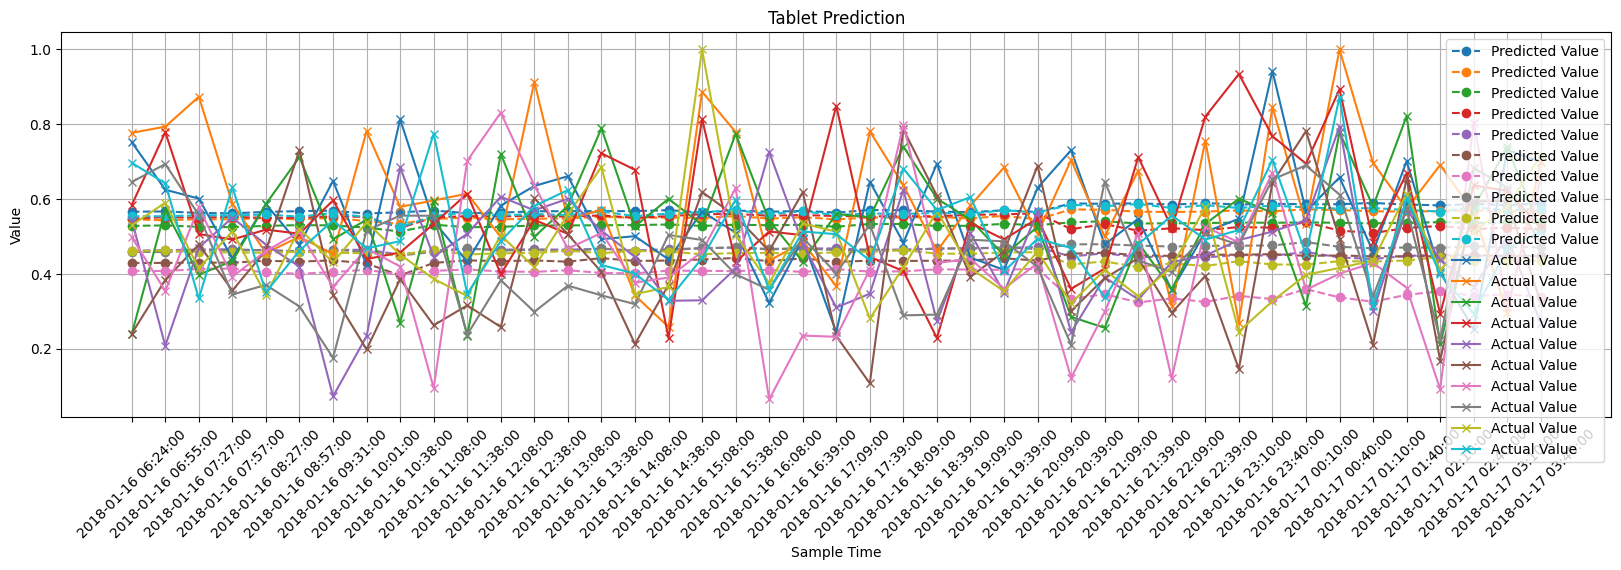

torch.Size([215, 10, 78])
torch.Size([215, 10])


2_16_50_0.01_Training Progress: 100%|██████████| 50/50 [00:01<00:00, 42.30epoch/s, Loss=0.0269]


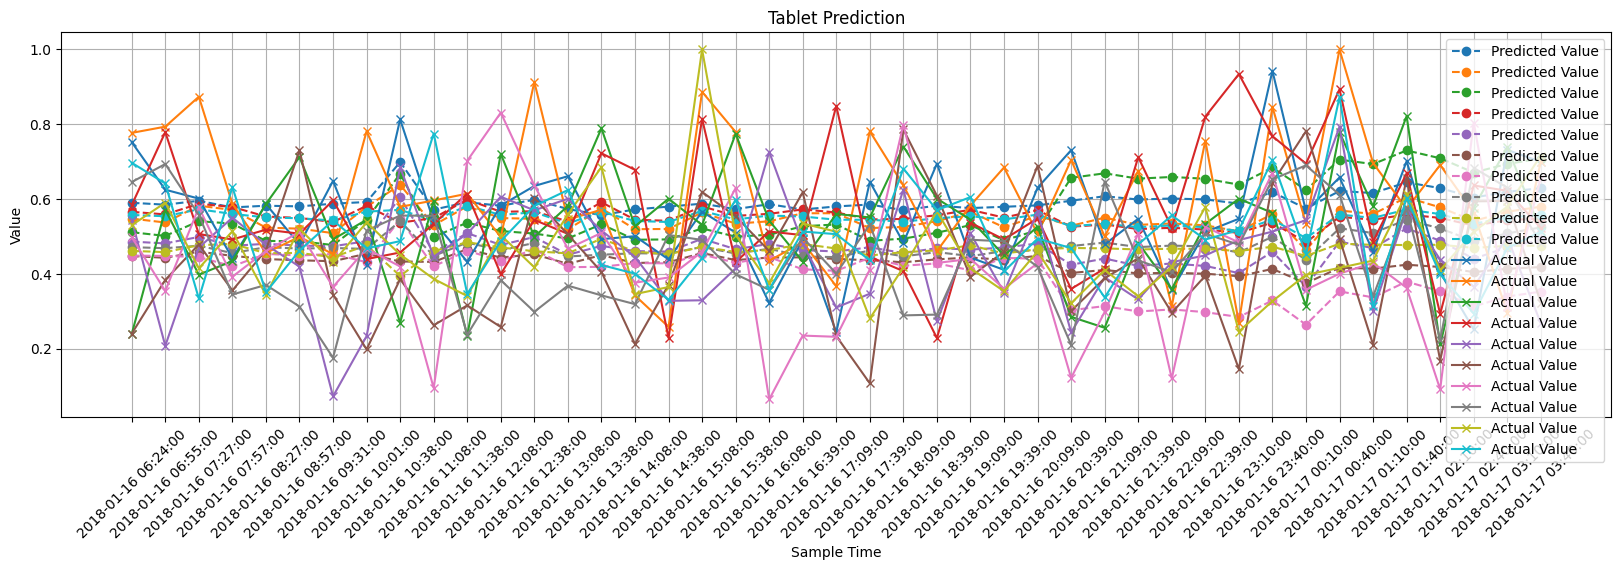

torch.Size([215, 10, 78])
torch.Size([215, 10])


2_16_50_0.1_Training Progress: 100%|██████████| 50/50 [00:00<00:00, 53.81epoch/s, Loss=0.0300]


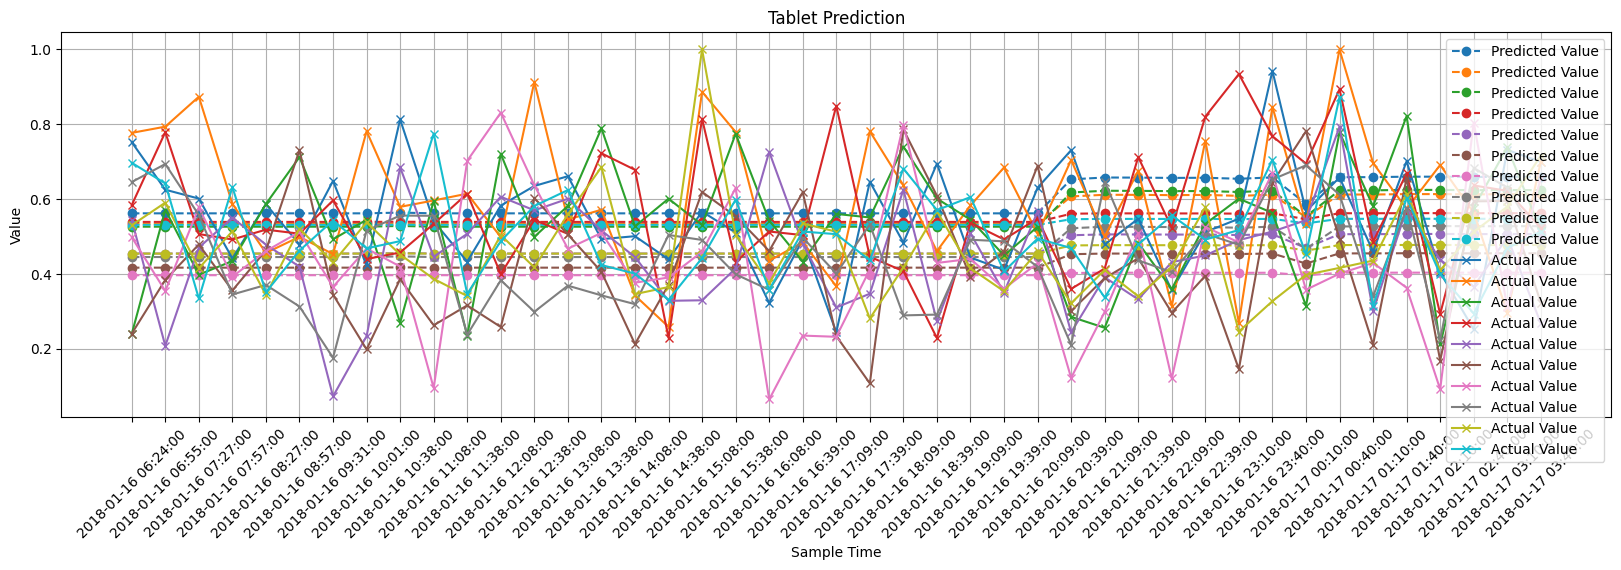

torch.Size([215, 10, 78])
torch.Size([215, 10])


2_16_100_0.0001_Training Progress: 100%|██████████| 100/100 [00:02<00:00, 49.68epoch/s, Loss=0.0364]


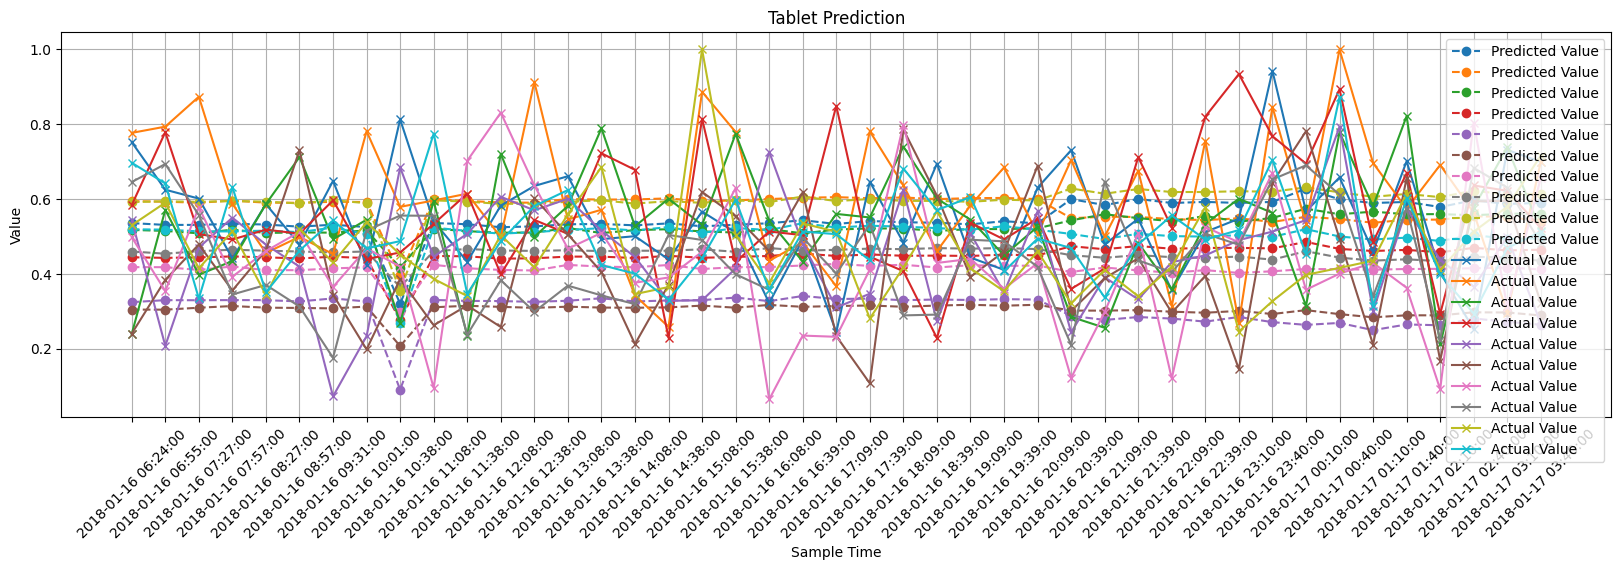

KeyboardInterrupt: 

In [27]:
# 直接做training
columns = result['API'].columns
targets = ['Tablet 1', 'Tablet 2', 'Tablet 3', 'Tablet 4', 'Tablet 5', 'Tablet 6', 'Tablet 7', 'Tablet 8', 'Tablet 9', 'Tablet 10']
featrues = columns.difference(targets + ["TimeStamp", 'sample_time', 'Batch', 'sample_id'])

input_size = len(featrues)
output_size = len(targets)
num_layers = [2,3,4,5]
hidden_layers = [16, 32, 64]
epochs = [50, 100, 200, 500, 1000]
lrs = [0.0001, 0.001, 0.01, 0.1]

results = {}

for num_layer in num_layers:
    for hidden_layer in hidden_layers:
        for epoch in epochs:
            for lr in lrs:
                model = LSTM_Model(model_name="API_LSTM", input_size=input_size, hidden_size=hidden_layer, output_size=output_size,num_layers=num_layer, epoch=epoch, lr=lr)
                results[f"{num_layer}_{hidden_layer}_{epoch}_{lr}"] = model.train(df=result['API'], target=targets)
                